In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns
from scipy import stats

In [41]:
# Reading Excel file into a DataFrame
df = pd.read_excel('Health Insurance Dataset.xlsx')
df

,age,sex,bmi,children,smoker,region,charges,Level,score
0,19,female,27.900,0,yes,southwest,16884.92400,B,72
1,18,male,33.770,1,no,southeast,1725.55230,C,69
2,28,male,33.000,3,no,southeast,4449.46200,B,90
3,33,male,22.705,0,no,northwest,21984.47061,A,47
4,32,male,28.880,0,no,northwest,3866.85520,C,76
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,B,90
1334,18,female,31.920,0,no,northeast,2205.98080,C,83
1335,18,female,36.850,0,no,southeast,1629.83350,B,61
1336,21,female,25.800,0,no,southwest,2007.94500,D,76


## Part I: Univariate and Bivariate Statistical Analyses and Visualizations ##
Two continuous variables are age and bmi, and two categorical variables are sex and smoker.

In [5]:
# Making a new DataFrame for identified variables
variables = ['age', 'bmi', 'sex', 'smoker']
df2 = df[variables]
df2

,age,bmi,sex,smoker
0,19,27.900,female,yes
1,18,33.770,male,no
2,28,33.000,male,no
3,33,22.705,male,no
4,32,28.880,male,no
...,...,...,...,...
1333,50,30.970,male,no
1334,18,31.920,female,no
1335,18,36.850,female,no
1336,21,25.800,female,no


In [6]:
# Univariate statistics for all the variables of df2
df2.describe(include = 'all')

,age,bmi,sex,smoker
count,1338.000000,1338.000000,1338,1338
unique,NaN,NaN,2,2
top,NaN,NaN,male,no
freq,NaN,NaN,676,1064
mean,39.207025,30.663397,NaN,NaN
std,14.049960,6.098187,NaN,NaN
min,18.000000,15.960000,NaN,NaN
25%,27.000000,26.296250,NaN,NaN
50%,39.000000,30.400000,NaN,NaN
75%,51.000000,34.693750,NaN,NaN


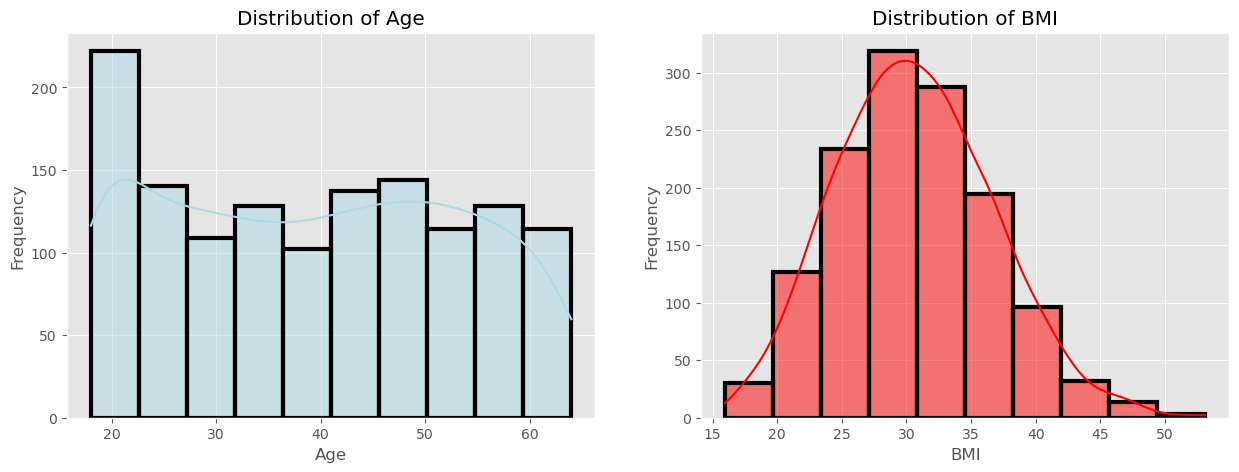

In [7]:
# Creating two histograms for the continuous variables age and bmi

# Figure size for each will be 15 by 5 (width and height)
plt.figure(figsize = (15, 5))

# Histogram for age
plt.subplot(1, 2, 1)
sns.histplot(df2['age'], bins = 10, kde = True, color = 'lightblue', edgecolor = 'black', linewidth = 3)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Histogram for bmi
plt.subplot(1, 2, 2)
sns.histplot(df2['bmi'], bins = 10, kde = True, color = 'red', edgecolor = 'black', linewidth = 3)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency');

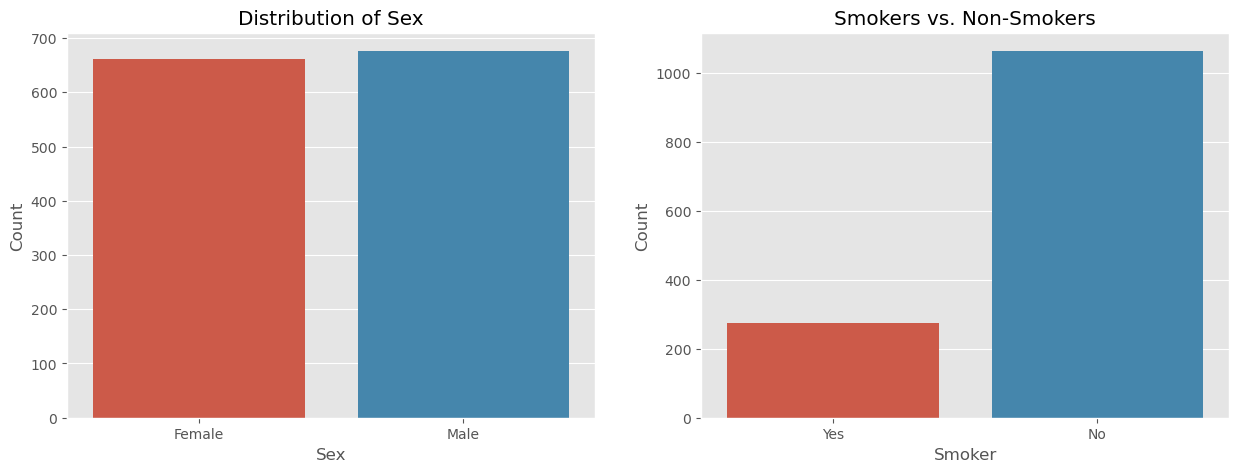

In [8]:
# Creating countplots for the categorical variables sex and smoker

# Figure size for each will be 15 by 5 (width and height)
plt.figure(figsize = (15, 5))

# Countplot for sex
plt.subplot(1, 2, 1)
sns.countplot(df2, x = 'sex', hue = 'sex')
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'], fontsize = 10);

# Countplot for smoker
plt.subplot(1, 2, 2)
sns.countplot(df2, x = 'smoker', hue = 'smoker')
plt.title('Smokers vs. Non-Smokers')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.xticks([0, 1], ['Yes', 'No'], fontsize = 10);

In [29]:
# Bivariate statistic
# t-test: BMI comparison by sex
male_bmi = df2[df2['sex'] == 'male']['bmi']
female_bmi = df2[df2['sex'] == 'female']['bmi']

# Performing the t-test
t_stat, p_value = stats.ttest_ind(male_bmi, female_bmi)

# Printing the results
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 1.6968
p-value: 0.0900


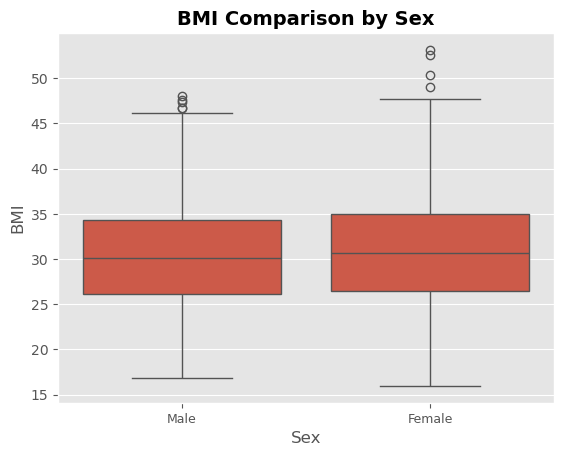

In [10]:
# Creating box plots to visualize t-test findings
sns.boxplot(x = 'sex', y = 'bmi', data = df2)
plt.title('BMI Comparison by Sex', fontsize = 14, fontweight = 'bold')
plt.xlabel('Sex', fontsize = 12)
plt.ylabel('BMI', fontsize = 12)
plt.xticks([0, 1], ['Male', 'Female'], fontsize = 9);

In [31]:
# Bivariate statistic
# t-test: smoker comparison by age
smokers_age = df2[df2['smoker'] == 'yes']['age']
non_smokers_age = df2[df2['smoker'] == 'no']['age']

# Performing the t-test
t_stat, p_value = stats.ttest_ind(smokers_age, non_smokers_age)

# Printing the results
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: -0.9148
p-value: 0.3605


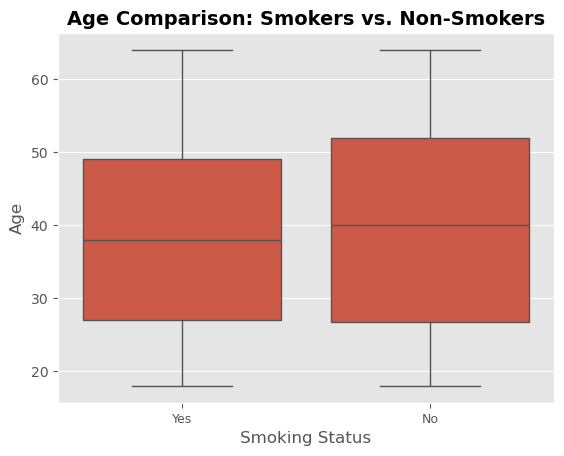

In [12]:
# Creating a box plots to visualize t-test findings
sns.boxplot(x = 'smoker', y = 'age', data = df2)
plt.title('Age Comparison: Smokers vs. Non-Smokers', fontsize = 14, fontweight = 'bold')
plt.xlabel('Smoking Status', fontsize = 12)
plt.ylabel('Age', fontsize = 12)
plt.xticks([0, 1], ['Yes', 'No'], fontsize = 9);

## Part II: Parametric Statistical Testing ##

In [33]:
# Parametric statistical test: t-test
print("t-test: Comparing BMI between the Northeast and Southwest Regions")
print()

# Creating two groups for the northeast and southwest regions
northeast = df[df['region'] == 'northeast']['bmi']
southwest = df[df['region'] == 'southwest']['bmi']

# Determining sample sizes and variance
print(f"Northeast Region Sample Size: {northeast.count()}")
print(f"Southwest Region Sample Size: {southwest.count()}")
print()
print(f"Northeast Region Variance: {northeast.var():.4f}")
print(f"Southwest Region Variance: {southwest.var():.4f}")
print()

# Performing a t-test
t_stat, p_value = stats.ttest_ind(northeast, southwest)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-test: Comparing BMI between the Northeast and Southwest Regions

Northeast Region Sample Size: 324
Southwest Region Sample Size: 325

Northeast Region Variance: 35.2541
Southwest Region Variance: 32.3970

t-statistic: -3.1169
p-value: 0.0019


## Part III: Nonparametric Statistical Testing ##

In [35]:
# Nonparametric statistical test: Mann-Whitney U test
from scipy.stats import mannwhitneyu

print("Mann-Whitney U Test: Comparing Health Scores Between Clients With/Without Children")
print()

# Splitting the data by clients with/without children
with_children = df[df['children'] > 0]['score']
without_children = df[df['children'] == 0]['score']

# Performing the Mann-Whitney U test
u_stat, p_value = mannwhitneyu(with_children, without_children)
print(f"U statistic: {u_stat}")
print(f"p-value: {p_value:.4f}")

Mann-Whitney U Test: Comparing Health Scores Between Clients With/Without Children

U statistic: 206024.0
p-value: 0.0583
